In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
data = pd.read_csv("C:/Users/Ankit_/Downloads/Datasets/Housing.csv")

In [36]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [37]:
data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [38]:
data.columns = data.columns.str.replace(' ', '_').str.lower()

In [39]:
data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [40]:
#Convert categorical → numeric # yes/no → 1/0

cols = ['mainroad','guestroom','basement','hotwaterheating',
        'airconditioning','prefarea']

for col in cols:
    data[col] = data[col].map({'yes':1, 'no':0})

In [41]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [42]:
print(data.dtypes)

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad             int64
guestroom            int64
basement             int64
hotwaterheating      int64
airconditioning      int64
parking              int64
prefarea             int64
furnishingstatus    object
dtype: object


In [43]:
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

In [44]:
data.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    uint8
furnishingstatus_unfurnished       uint8
dtype: object

In [45]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [46]:
# Define X and y
X = data.drop('price', axis=1)
y = data['price']

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
# Train
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [51]:
# Coefficients
print(model.coef_)
print(model.intercept_)

[ 578335.75242886   95827.00521424  482772.50096845  446965.36743854
  151305.73163132   83114.49619505  195252.66854952  194241.22272989
  360029.26808386  244395.8011858   238364.40814014   36777.64495562
 -160531.78114259]
4782853.073394495


In [52]:
# Prediction
y_pred = model.predict(X_test)

In [53]:
# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1090249641230.1239
R2 Score: 0.6585429213347469


In [54]:
print(data.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


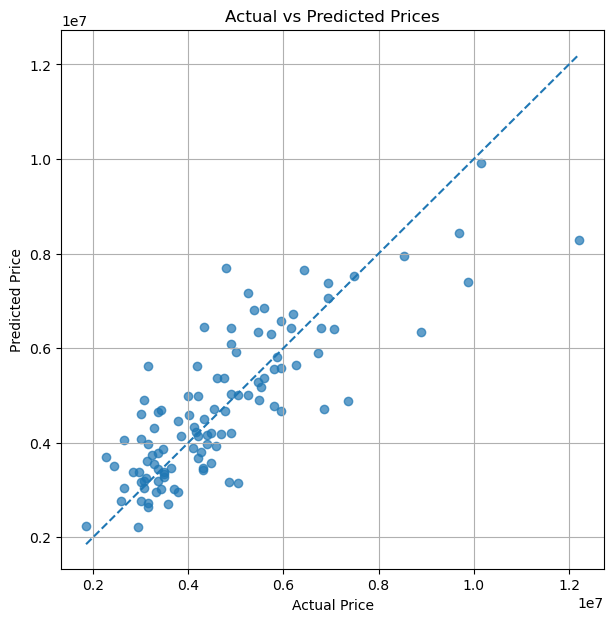

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Scatter plot
plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.grid(True)
plt.show()

In [38]:
print("Actual:", y_test.values[:5])
print("Predicted:", y_pred[:5])

Actual: [2835000 4200000 6930000 4340000 2450000]
Predicted: [3376560.77802494 4149294.20122039 7066187.41745718 6444114.34515627
 3500392.52669152]


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    int64 
 6   guestroom         545 non-null    int64 
 7   basement          545 non-null    int64 
 8   hotwaterheating   545 non-null    int64 
 9   airconditioning   545 non-null    int64 
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    int64 
 12  furnishingstatus  545 non-null    object
dtypes: int64(12), object(1)
memory usage: 55.5+ KB


In [14]:
print(data.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


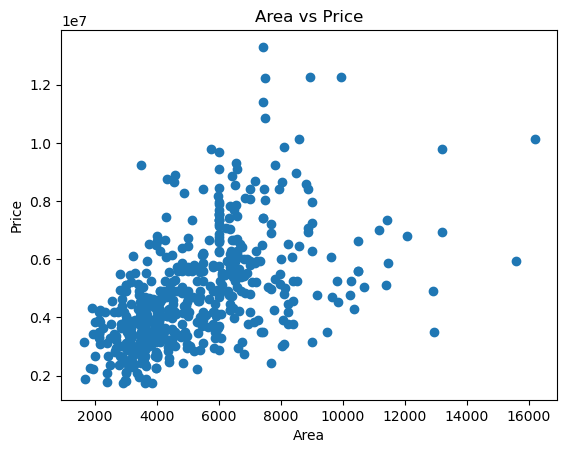

In [21]:
#Understand how input Area affects output (price) 
plt.scatter(data['area'], data['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

C:\Users\Ankit_\AppData\Local\Temp\ipykernel_17256\932294514.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(data.corr(), annot=True)


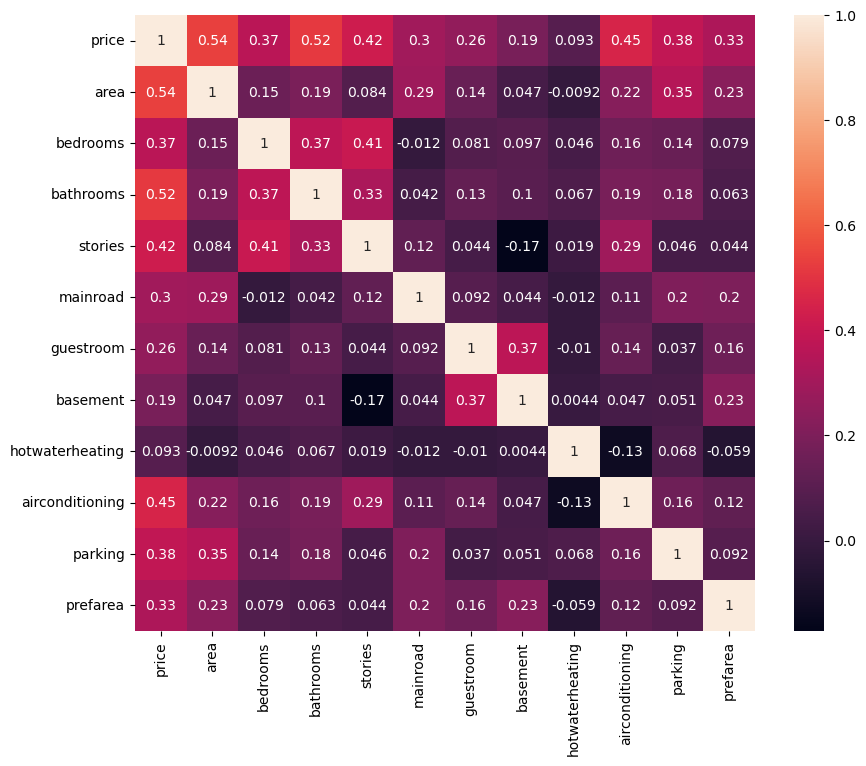

In [17]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True)
plt.show()

In [22]:
#Top features affecting price

corr = data.corr()['price'].sort_values(ascending=False)
print(corr)

price              1.000000
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394
bedrooms           0.366494
prefarea           0.329777
mainroad           0.296898
guestroom          0.255517
basement           0.187057
hotwaterheating    0.093073
Name: price, dtype: float64


C:\Users\Ankit_\AppData\Local\Temp\ipykernel_17256\270432598.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = data.corr()['price'].sort_values(ascending=False)


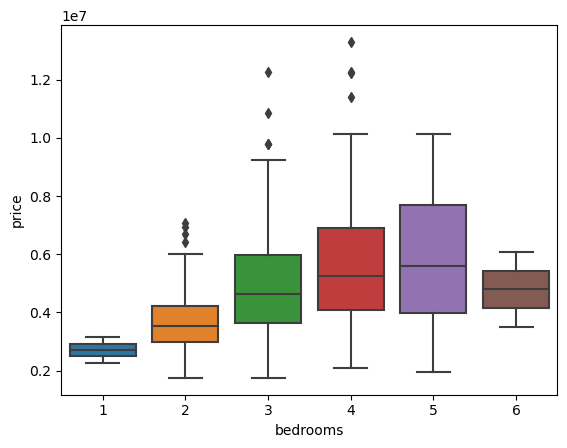

In [18]:
sns.boxplot(x='bedrooms', y='price', data=data)
plt.show()

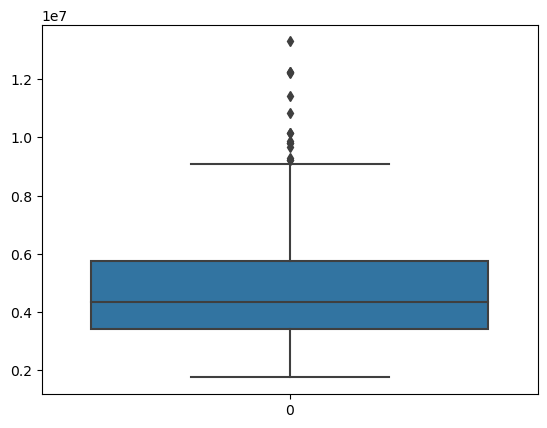

In [19]:
sns.boxplot(data['price'])
plt.show()